In [1]:
from google.cloud import bigquery

client = bigquery.Client.from_service_account_json('/Users/mudkip/Desktop/hdb-resale-497709-d35abae8ec16.json')

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
query = """
    SELECT year, resale_price
    FROM `hdb-resale-497709.hdb_transform_marts.fact_sales`
"""

df = client.query(query).to_dataframe()

/opt/anaconda3/envs/env/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [44]:
df.dtypes

year             Int64
resale_price    object
dtype: object

In [45]:
df['resale_price'] = pd.to_numeric(df['resale_price'])

In [46]:
df.dtypes

year              Int64
resale_price    float64
dtype: object

In [47]:
data = df.groupby('year').agg('mean').round(2)

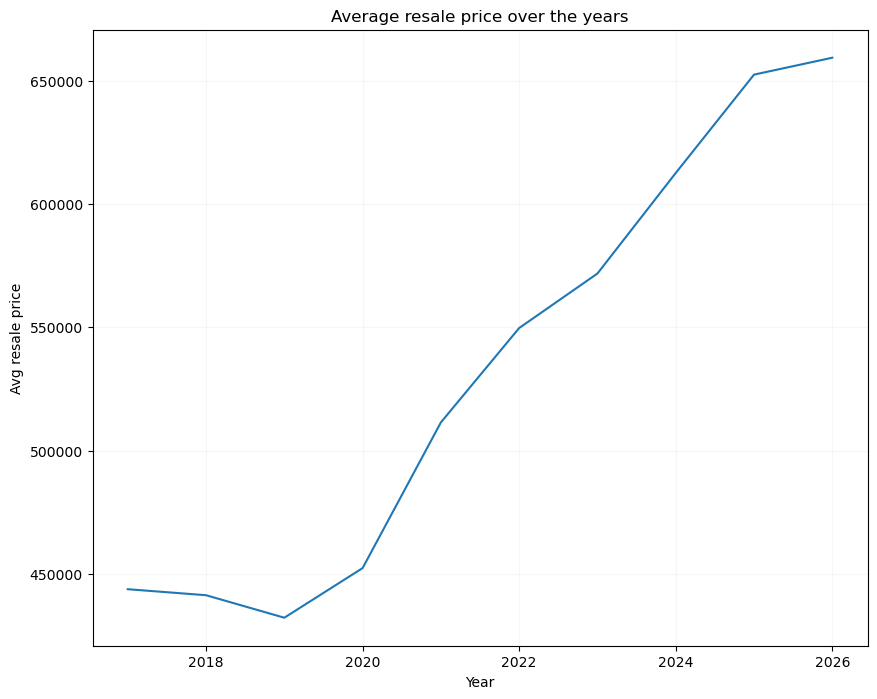

In [48]:
fig, axes = plt.subplots(1, 1, figsize=(10, 8))

sns.lineplot(data=data, x='year', y='resale_price', ax=axes, errorbar=None)
axes.set_title("Average resale price over the years")
axes.set_xlabel("Year")
axes.set_ylabel("Avg resale price")
axes.grid(True, alpha=0.1)



In [49]:
query = """
    SELECT l.town, s.resale_price
    FROM `hdb-resale-497709.hdb_transform_marts.fact_sales` AS s
    JOIN `hdb-resale-497709.hdb_transform_marts.dim_location` AS l
    ON s.location_id = l.location_id
"""

df = client.query(query).to_dataframe()

/opt/anaconda3/envs/env/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [50]:
df.dtypes

town            object
resale_price    object
dtype: object

In [51]:
df['resale_price'] = pd.to_numeric(df['resale_price'])

In [52]:
df.dtypes

town             object
resale_price    float64
dtype: object

In [53]:
data = df.groupby('town')['resale_price'].mean().sort_values(ascending=False).reset_index()

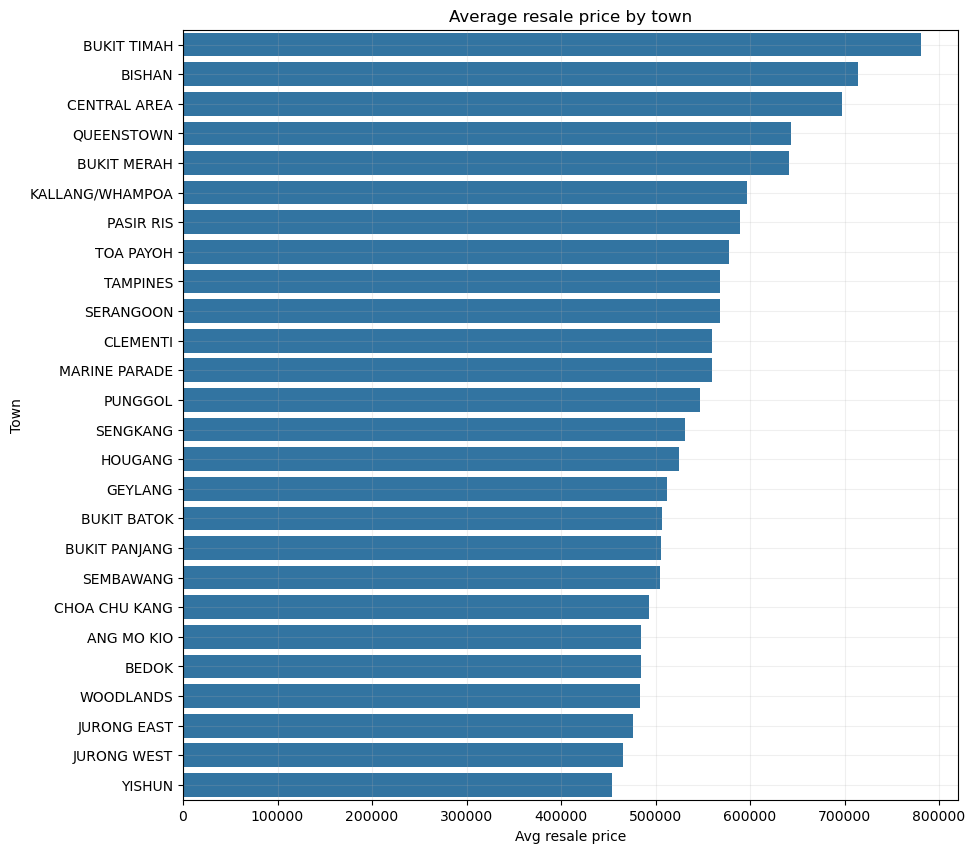

In [56]:
fig, axes = plt.subplots(1, 1, figsize=(10, 10))

sns.barplot(data=data, x='resale_price', y='town', ax=axes, errorbar=None)
axes.set_title("Average resale price by town")
axes.set_xlabel("Avg resale price")
axes.set_ylabel("Town")
axes.grid(True, alpha=0.2)

